## MODELLING

### 1. Logistic Regression- Baseline

A simple baseline model is used as the starting point for the AgriScore credit scoring system.
The purpose of a baseline model is not to achieve the highest accuracy, but to establish a reference performance level that future models can be compared against.

Logistic Regression is used as the primary baseline model because:

- It is simple, fast, and easy to interpret
- It provides probabilistic outputs (useful for credit risk scoring)
- It assumes a linear relationship between features and the target variable
- It works well as a first benchmark in classification problems

In the context of AgriScore, Logistic Regression helps us understand how individual factors such as yield, stability, and household characteristics contribute to the likelihood of a farmer being creditworthy.

### Importing Libraries

In this section, we import the necessary Python libraries for data analysis and preprocessing.



In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import seaborn as sns

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="viridis")
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In this step, we load the cleaned dataset into the notebook using pandas.



In [2]:
import pandas as pd

# '..' moves out of Notebooks, then we enter 'Data sets'
final_data= pd.read_csv("../Data sets/Final_dataset.csv")
final_data.head()

,Unnamed: 0,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_size,farm_work,livestock,inorganic_fertilizer,...,cashflow_volatility,balance_stability,fraud_rate,input_efficiency,climate_risk_score,hh_shock,drought_shock,dist_market,country,main_crop_clean
0,0,13.0,0.3,44.4,1.0,1.0,3.103942,1.0,0.0,0.0,...,3.107012,4.965882e+07,0.636364,0.0,0.237516,1.0,0.000000,60.700001,Tanzania,OTHER
1,1,4.0,1.0,81.0,1.0,1.0,3.658361,0.0,0.0,0.0,...,1.592171,2.705629e+07,0.733333,0.0,0.258148,1.0,0.166667,60.700001,Tanzania,OTHER
2,2,4.0,3.0,72.0,1.0,1.0,1.210011,1.0,0.0,0.0,...,1.814533,1.185635e+08,0.250000,0.0,0.176846,0.0,0.000000,60.700001,Tanzania,MAIZE
3,3,2.0,1.0,31.0,0.0,1.0,3.354847,1.0,0.0,0.0,...,0.000000,2.933951e+07,0.000000,0.0,0.319816,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT
4,4,3.0,0.5,38.0,0.0,1.0,6.689459,1.0,0.0,0.0,...,1.300629,2.887447e+07,0.600000,0.0,0.226742,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT


In [3]:
final_data.shape

(11408, 34)

In [4]:
final_data.columns

Index(['Unnamed: 0', 'hh_size', 'hh_dependency_ratio', 'age_manager',
       'hh_primary_education', 'hh_formal_education', 'farm_size', 'farm_work',
       'livestock', 'inorganic_fertilizer', 'fertilizer_per_ha', 'yield_kg_ha',
       'yield_stability', 'yield_per_ha', 'rainfall_mm', 'soil_quality_index',
       'soil_npk', 'drought_risk', 'climate_stress_index', 'crop_health_index',
       'tx_frequency', 'total_volume', 'avg_transaction',
       'input_purchase_ratio', 'cashflow_volatility', 'balance_stability',
       'fraud_rate', 'input_efficiency', 'climate_risk_score', 'hh_shock',
       'drought_shock', 'dist_market', 'country', 'main_crop_clean'],
      dtype='str')

In [5]:
final_data.isnull().sum()

Unnamed: 0              0
hh_size                 0
hh_dependency_ratio     0
age_manager             0
hh_primary_education    0
hh_formal_education     0
farm_size               0
farm_work               0
livestock               0
inorganic_fertilizer    0
fertilizer_per_ha       0
yield_kg_ha             0
yield_stability         0
yield_per_ha            0
rainfall_mm             0
soil_quality_index      0
soil_npk                0
drought_risk            0
climate_stress_index    0
crop_health_index       0
tx_frequency            0
total_volume            0
avg_transaction         0
input_purchase_ratio    0
cashflow_volatility     0
balance_stability       0
fraud_rate              0
input_efficiency        0
climate_risk_score      0
hh_shock                0
drought_shock           0
dist_market             0
country                 0
main_crop_clean         0
dtype: int64

In [6]:
# import seaborn as sns

# sns.boxplot(x=final_data['good_borrower'], y=final_data['yield_per_ha'])

### Creating the Target Variable: Good Borrower

In this step, we define the target variable `good_borrower`, which represents whether a farmer is creditworthy or not.

A farmer is labeled as a **good borrower (1)** if they meet the following conditions:

- Their yield per hectare is above the median value  
- Their balance stability is above the median value  
- Their climate risk score is below the median value  

Otherwise, they are labeled as a **bad borrower (0)**.

This rule-based approach helps us create a clear classification target for the machine learning model.

In [7]:
final_data['good_borrower'] = np.where(
    (
        (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()) &
        (final_data['balance_stability'] > final_data['balance_stability'].median()) &
        (final_data['climate_risk_score'] < final_data['climate_risk_score'].median())
    ),
    1,
    0
)

#### Encoding Categorical Variables

In this step, we convert categorical variables into numerical format using **One-Hot Encoding**.


In [8]:
final_data = pd.get_dummies(
    final_data,
    columns=['country', 'main_crop_clean'],
    drop_first=True
)

#### Defining Features (X) and Target (y)

Here, we separate the dataset into:

- **X (features):** All independent variables used for prediction  
- **y (target):** The `good_borrower` column, which we aim to predict  

This step prepares the data for model training.

In [9]:
X = final_data.drop('good_borrower', axis=1)

y = final_data['good_borrower']

In [10]:
# import matplotlib.pyplot as plt
# plt.scatter(final_data['yield_per_ha'], final_data['balance_stability'],
#             c=final_data['good_borrower'])

#### Splitting the Dataset 

The dataset is split into training and testing sets using an 80/20 ratio. 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

<Axes: xlabel='good_borrower'>

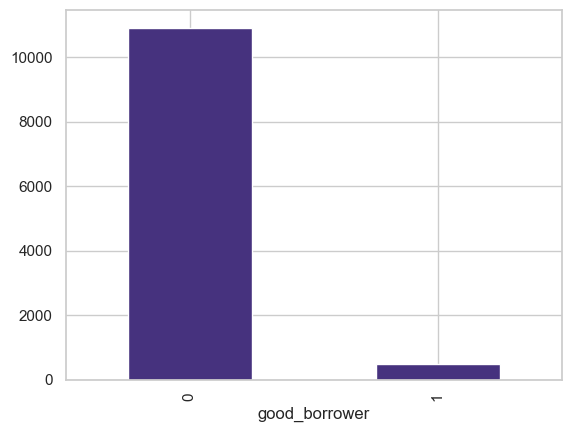

In [12]:
final_data['good_borrower'].value_counts().plot(kind='bar')

#### Handling Class Imbalance Using SMOTE

To address the imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data. SMOTE generates synthetic examples of the minority class (good borrowers) to create a balanced dataset. This helps the model learn patterns from both classes more effectively and improves its ability to correctly identify good borrowers.

In [13]:

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#### Check new class balance

<Axes: xlabel='good_borrower'>

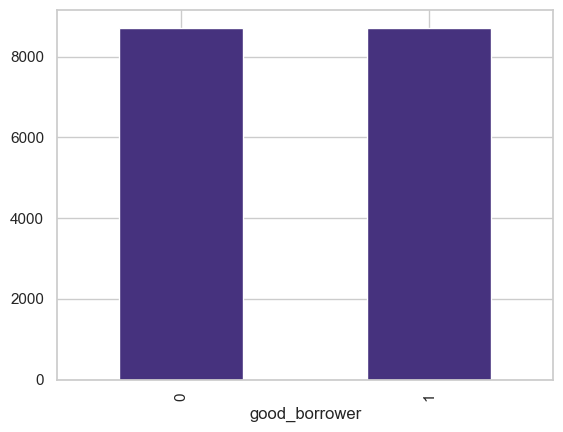

In [14]:
y_train_resampled.value_counts().plot(kind='bar')

#### Training the Logistic Regression Model

In this step, we train a Logistic Regression model on the training data.


In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Making Predictions

After training the model, we use it to predict borrower status on the test dataset.

The output `y_pred` represents the model's predicted classification:
- 1 → Good borrower  
- 0 → Bad borrower  

These predictions will be compared with actual values for evaluation.

In [16]:
y_pred = model.predict(X_test)

#### Model Evaluation

We evaluate the model using standard classification metrics:

- **Accuracy Score** → Overall performance of the model  
- **Classification Report** → Includes precision, recall, and F1-score  

These metrics help us understand how well the model is performing in identifying good and bad borrowers.

Accuracy: 0.8742331288343558
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2196
           1       0.21      0.83      0.33        86

    accuracy                           0.87      2282
   macro avg       0.60      0.85      0.63      2282
weighted avg       0.96      0.87      0.91      2282



<Axes: >

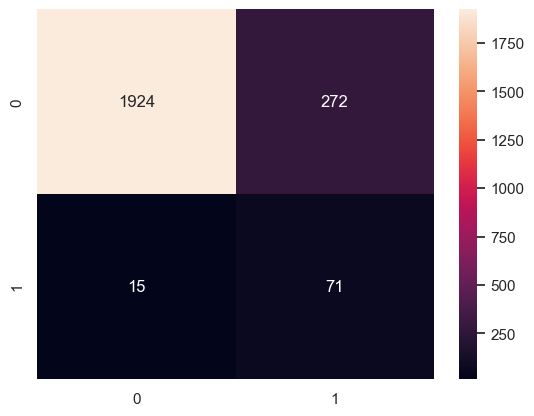

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

#### Model Performance Insights

The model achieved an accuracy of **87.4%**, showing a balance between correctly and incorrectly classified cases. It performs very well in identifying class 0 (bad borrowers), with high precision (0.99) and strong recall (0.88), meaning most bad borrowers are correctly detected.

For class 1 (good borrowers), the model shows a much improved recall of **0.83**, meaning it correctly identifies most good borrowers. However, precision is lower at **0.21**, indicating that many borrowers predicted as good are actually bad, leading to a higher number of false positives.

Overall, the model has improved its ability to identify good borrowers, but this comes with an increase in misclassification of bad borrowers. This reflects a trade-off between correctly identifying creditworthy farmers and minimizing risky loan approvals.

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
20,tx_frequency,0.068890
3,age_manager,0.021302
24,cashflow_volatility,0.020549
23,input_purchase_ratio,0.007747
1,hh_size,0.007413
6,farm_size,0.006700
32,main_crop_clean_MAIZE,0.004113
26,fraud_rate,0.002683
34,main_crop_clean_NUTS,0.002100
35,main_crop_clean_OTHER,0.002043
